# Capstone Project

In [1]:
%reset -f

In [2]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
np.random.seed(42)


In [3]:
# LOADING FUNCTION VALUES
def load_function(fn_num):
    X_read = np.load(f'initial_data_2/function_{fn_num}/initial_inputs.npy')
    y_read = np.load(f'initial_data_2/function_{fn_num}/initial_outputs.npy')
    cols = [f'x{i+1}' for i in range(X_read.shape[1])]
    X = pd.DataFrame(X_read, columns=cols)
    y = pd.Series(y_read, name='y')
    return X, y

X1, y1 = load_function(1)
X2, y2 = load_function(2)
X3, y3 = load_function(3)
X4, y4 = load_function(4)
X5, y5 = load_function(5)
X6, y6 = load_function(6)
X7, y7 = load_function(7)
X8, y8 = load_function(8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

In [4]:
# DEFINING ACQUISITION FUNCTIONS

def acq_PI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * (y_vals.max() - y_vals.min() + 1e-9))  # ← float()
    z = (mu - y_max - xi) / (sigma + 1e-9)
    return norm.cdf(z)

def acq_EI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * (y_vals.max() - y_vals.min() + 1e-9))  # ← float()
    z = (mu - y_max - xi) / (sigma + 1e-9)
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-10] = 0
    return ei

def acq_UCB(mu, sigma, t, d=1, delta=0.1):
    """
    Annealing UCB: beta grows with iteration t.
    t    = current iteration number (1-indexed)
    d    = input dimensionality
    delta = confidence parameter (0.1 is standard)
    """
    beta = np.sqrt(2 * np.log(d * t**2 * np.pi**2 / (6 * delta)))
    return mu + beta * sigma



In [5]:
# DEFINING BAYESIAN OPTIMISATION FUNCTION

def run_bo(fn_num, n_candidates=2000):
    X = all_X[fn_num - 1].values
    Y = all_y[fn_num - 1].values
    n_dim = X.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()
    y_max = Y.max()

    kernel = RBF(length_scale=0.3, length_scale_bounds=(1e-3, 10.0))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=5,
        normalize_y=True
    )
    gp.fit(X, Y)

    # Random candidate grid — avoids exponential grid blowup in high-D
    candidates = np.random.uniform(1e-6, 0.999999, size=(n_candidates, n_dim))
    mu, sigma = gp.predict(candidates, return_std=True)

    acq_results = {
        'EI':  candidates[np.argmax(acq_EI(mu, sigma, y_max, Y))],
        'UCB': candidates[np.argmax(acq_UCB(mu, sigma, t=len(Y), d=n_dim))],
        'PI':  candidates[np.argmax(acq_PI(mu, sigma, y_max, Y))],
    }

    rows = []
    for acq_name, x_next in acq_results.items():
        pred_y = float(gp.predict(x_next.reshape(1, -1))[0])
        row = {
            'function':     fn_num,
            'dimensions':   n_dim,
            'acquisition':  acq_name,
            'predicted_y':  round(pred_y, 6),
            'y_max_so_far': round(float(y_max), 6),
            'submission':   '-'.join([f'{v:.6f}' for v in x_next]),
        }
        for i, col in enumerate(dim_cols):
            row[f'{col}_suggested'] = round(float(x_next[i]), 6)
        rows.append(row)

    return pd.DataFrame(rows), gp

print('run_bo() defined.')
print('Usage: df_suggestions, gp = run_bo(fn_num=1)')

run_bo() defined.
Usage: df_suggestions, gp = run_bo(fn_num=1)


In [6]:
# DEFINING PLOTTING FUNCTION 

def plot_function(fn_num, df_all=None):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             squeeze=False)

    y_rank = y.rank(pct=True)

    # ── Pre-fetch BO suggestions for this function
    acq_styles = {
        'EI':  dict(color='green',  linestyle='--', linewidth=2.5, zorder=5),
        'UCB': dict(color='purple', linestyle='-.',  linewidth=2.5, zorder=5),
        'PI':  dict(color='red',    linestyle=':',   linewidth=2.5, zorder=5),
    }
    fn_suggestions = None
    if df_all is not None:
        fn_suggestions = df_all[df_all['function'] == fn_num]
        print(f"F{fn_num}: {len(fn_suggestions)} suggestion rows, cols: {fn_suggestions.columns.tolist()}")

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax = axes[row][col_idx]

        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        z = np.polyfit(X[col], y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[col].min(), X[col].max(), 100)
        ax.plot(x_line, p(x_line), color='black', linewidth=1.5,
                linestyle='--', alpha=0.7, zorder=3)

        corr = X[col].corr(y)
        ax.set_title(f'{col} vs y  |  r={corr:.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        # ── Last submitted point (star marker)
        ax.scatter(X[col].iloc[-1], y.iloc[-1],
                   marker='*', s=300, color='gold',
                   edgecolors='black', linewidths=0.5,
                   zorder=6, label=f'last (y={y.iloc[-1]:.3e})')
        ax.legend(fontsize=7, loc='upper right')

        # ── Draw vertical lines inline — no separate function needed
        if fn_suggestions is not None:
            suggested_col = f'{col}_suggested'
            if suggested_col in fn_suggestions.columns:
                for _, srow in fn_suggestions.iterrows():
                    x_val = srow[suggested_col]
                    acq   = srow['acquisition']
                    ax.axvline(x=x_val, **acq_styles.get(acq, {}),
                               label=f"{acq}={x_val:.3f}")
                ax.legend(fontsize=7, loc='upper right')

    for idx in range(n_dim, n_rows * n_cols):
        row, col_idx = divmod(idx, n_cols)
        axes[row][col_idx].set_visible(False)

    fig.subplots_adjust(right=0.82)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='rainbow',
                                norm=plt.Normalize(vmin=y.min(), vmax=y.max()))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='y value')

    plt.suptitle(f'Function {fn_num} | {n_dim}D — Marginal Plots (x_i vs y)\n'
                 f'r = Pearson correlation | dashed = linear trend',
                 fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


In [7]:
# RUN BO ON ALL FUNCTIONS
 
all_suggestions = []
gps = {}

for fn in range(1, 9):
    df_sugg, gp = run_bo(fn)
    all_suggestions.append(df_sugg)
    gps[fn] = gp
    print(f'F{fn} done. Fitted kernel: {gp.kernel_}')

df_all = pd.concat(all_suggestions, ignore_index=True)
print(f'\nTotal rows: {len(df_all)} (8 functions x 3 acquisition functions)')
print(df_all[['function','dimensions','acquisition','y_max_so_far','predicted_y']].to_string(index=False))

F1 done. Fitted kernel: RBF(length_scale=0.0465)
F2 done. Fitted kernel: RBF(length_scale=0.122)
F3 done. Fitted kernel: RBF(length_scale=0.197)
F4 done. Fitted kernel: RBF(length_scale=0.519)
F5 done. Fitted kernel: RBF(length_scale=0.39)
F6 done. Fitted kernel: RBF(length_scale=0.489)
F7 done. Fitted kernel: RBF(length_scale=0.28)
F8 done. Fitted kernel: RBF(length_scale=0.914)

Total rows: 24 (8 functions x 3 acquisition functions)
 function  dimensions acquisition  y_max_so_far  predicted_y
        1           2          EI      0.000000     0.000020
        1           2         UCB      0.000000    -0.000167
        1           2          PI      0.000000     0.000181
        2           2          EI      0.611205     0.556381
        2           2         UCB      0.611205     0.349734
        2           2          PI      0.611205     0.610723
        3           3          EI     -0.028009    -0.042855
        3           3         UCB     -0.028009    -0.086688
        3   

In [8]:
# SELECTING ACQUISITION FUNCTION

df_best = (
    df_all
    .sort_values('predicted_y', ascending=False)
    .groupby('function')
    .first()
    .reset_index()
    [['function','dimensions','acquisition','y_max_so_far','predicted_y','submission']]
    .set_index('function')
)

print('Best acquisition per function (by predicted_y):')
print(df_best.to_string())
print('\n'.join(df_best['submission'].values))

Best acquisition per function (by predicted_y):
          dimensions acquisition  y_max_so_far  predicted_y                                                               submission
function                                                                                                                            
1                  2          PI      0.000000     0.000181                                                        0.751177-0.753868
2                  2          PI      0.611205     0.610723                                                        0.720333-0.918284
3                  3          PI     -0.028009    -0.027991                                               0.376148-0.467838-0.419390
4                  4          EI     -2.337431    -2.586431                                      0.438101-0.470414-0.278728-0.379791
5                  4          EI   1410.822472  1509.268712                                      0.433955-0.573328-0.967518-0.982559
6                  5 

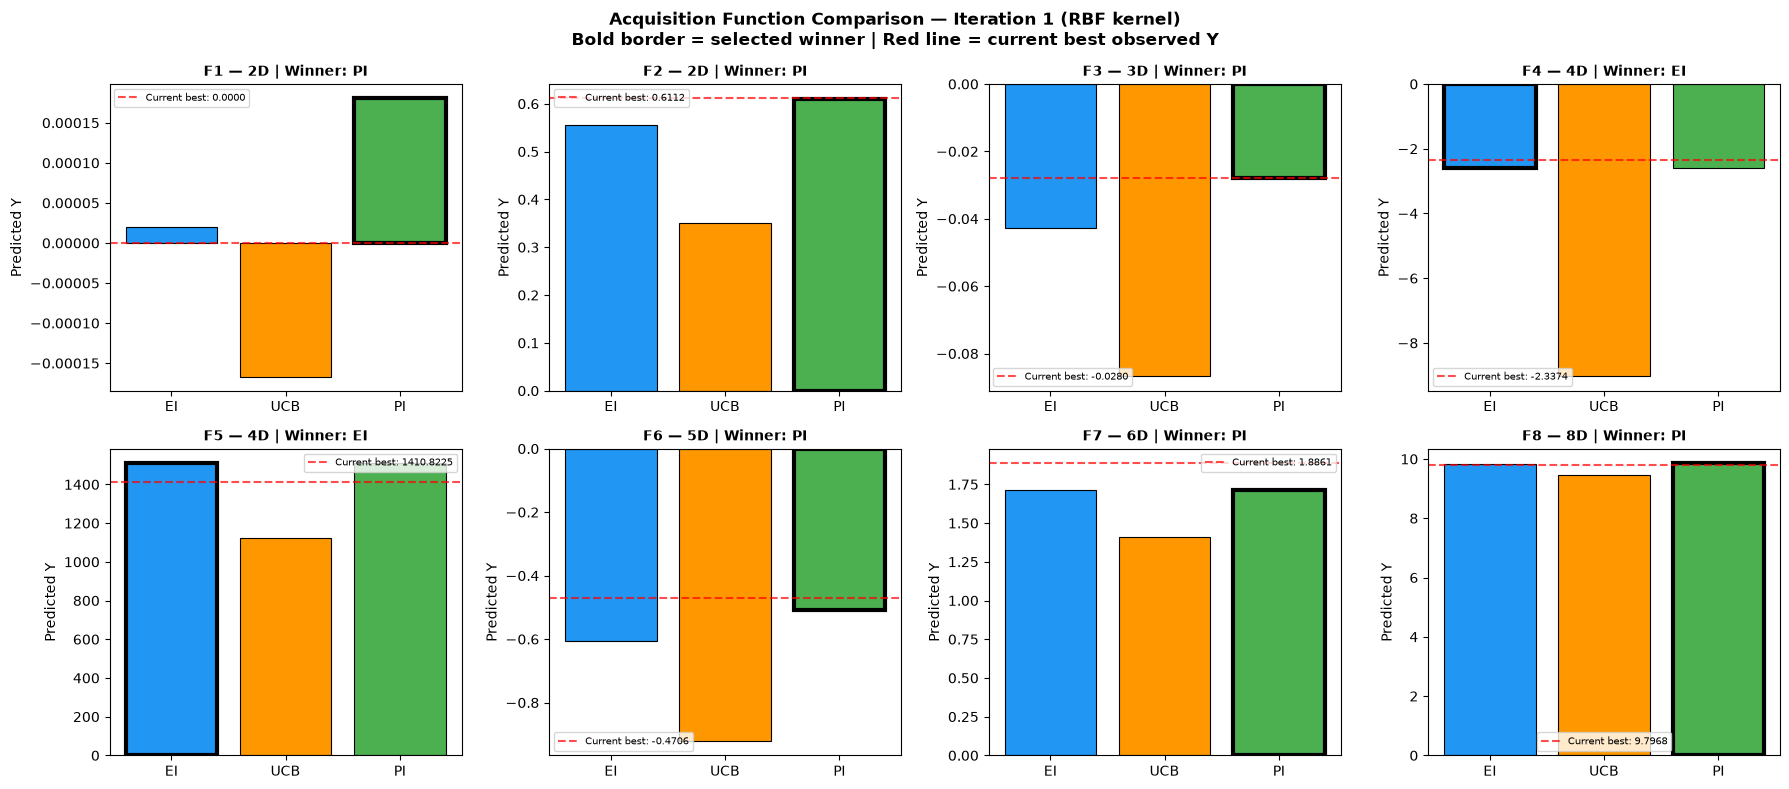

In [9]:
# COMPARING ACQUISITION FUNCTIONS
 
colours = {'EI': '#2196F3', 'UCB': '#FF9800', 'PI': '#4CAF50'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for fn in range(1, 9):
    ax = axes[fn - 1]
    df_fn = df_all[df_all['function'] == fn]
    winner = df_best.loc[fn, 'acquisition']
    y_current_best = df_best.loc[fn, 'y_max_so_far']

    acq_names   = df_fn['acquisition'].tolist()
    pred_ys     = df_fn['predicted_y'].tolist()
    bar_cols    = [colours[a] for a in acq_names]
    edge_widths = [3 if a == winner else 0.8 for a in acq_names]

    ax.bar(acq_names, pred_ys, color=bar_cols,
           edgecolor='black', linewidth=edge_widths)
    ax.axhline(y_current_best, color='red', linestyle='--',
               alpha=0.7, label=f'Current best: {y_current_best:.4f}')
    ax.set_title(
        f'F{fn} — {all_X[fn-1].shape[1]}D | Winner: {winner}',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Predicted Y')
    ax.legend(fontsize=7)

fig.suptitle(
    'Acquisition Function Comparison — Iteration 1 (RBF kernel)\n'
    'Bold border = selected winner | Red line = current best observed Y',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

F1: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


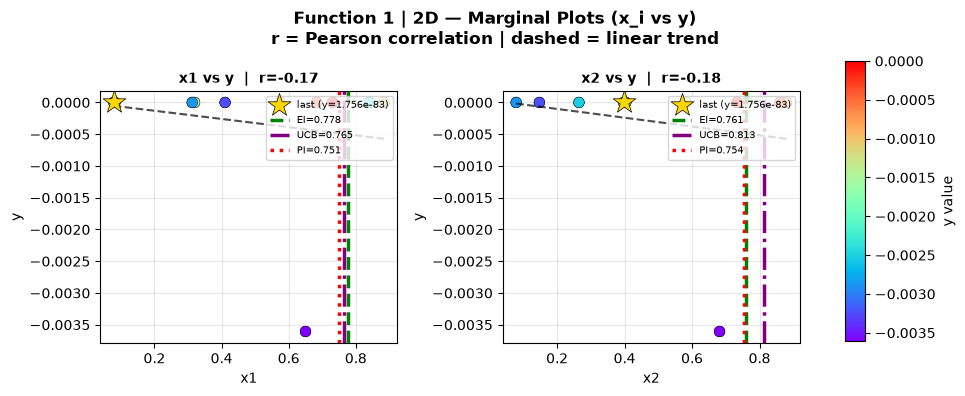

F2: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


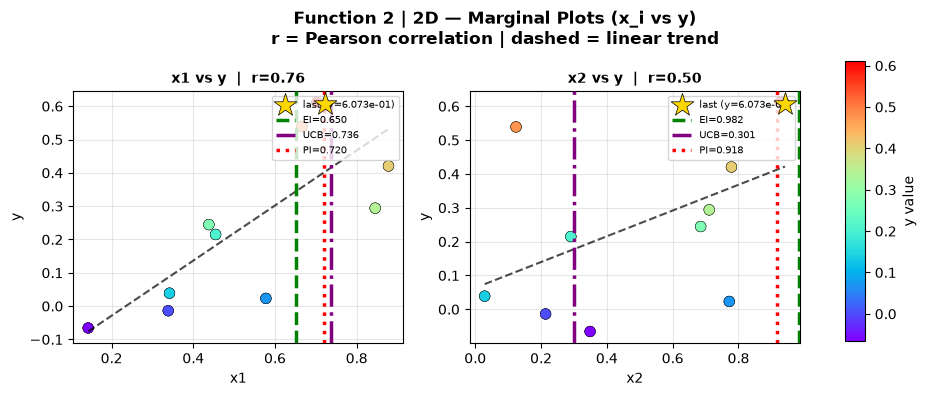

F3: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


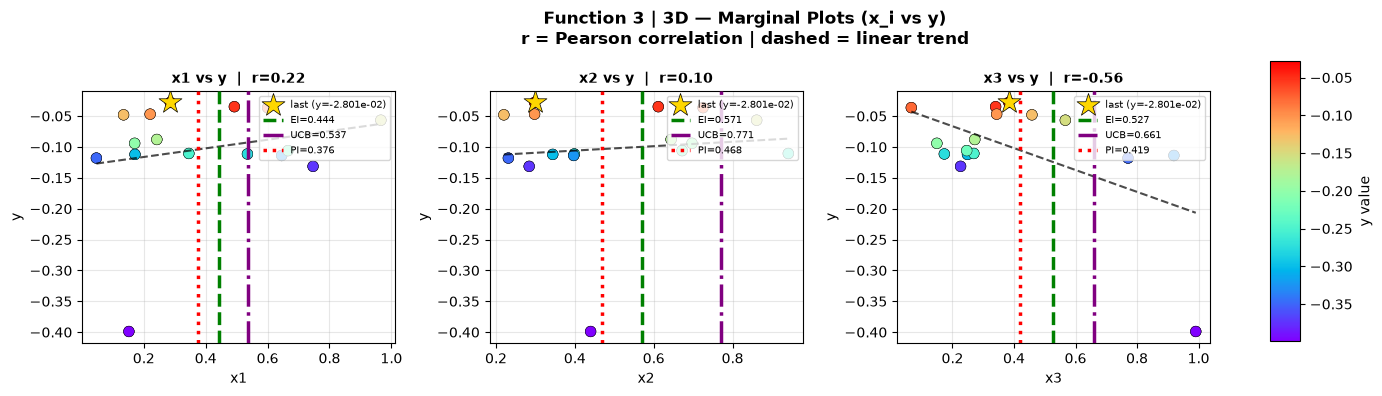

F4: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


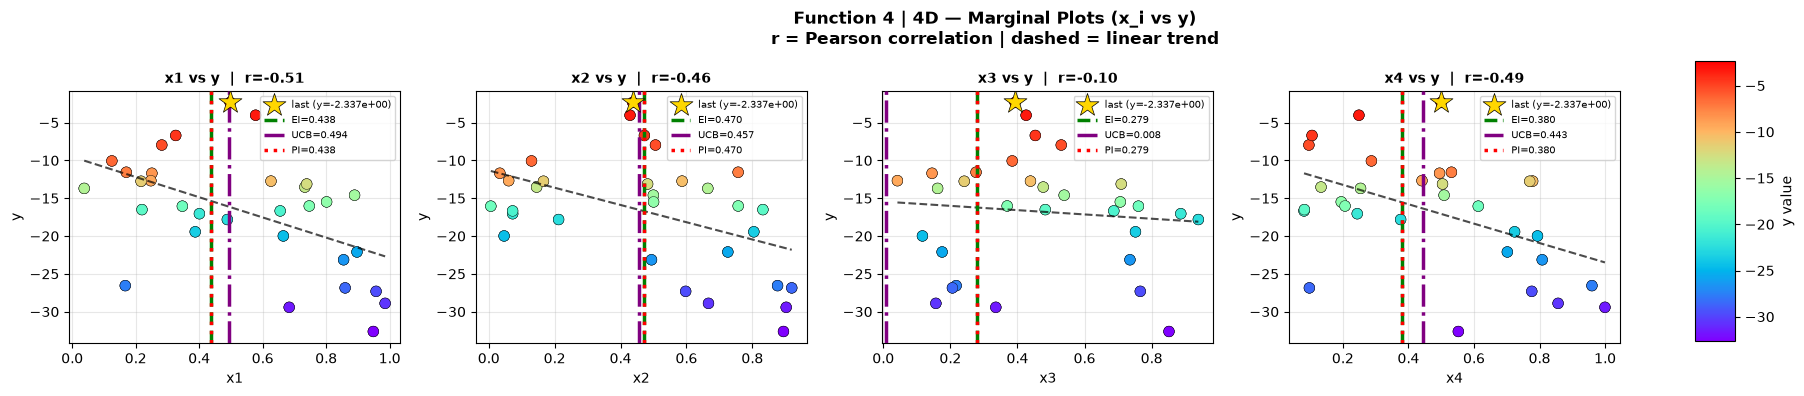

F5: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


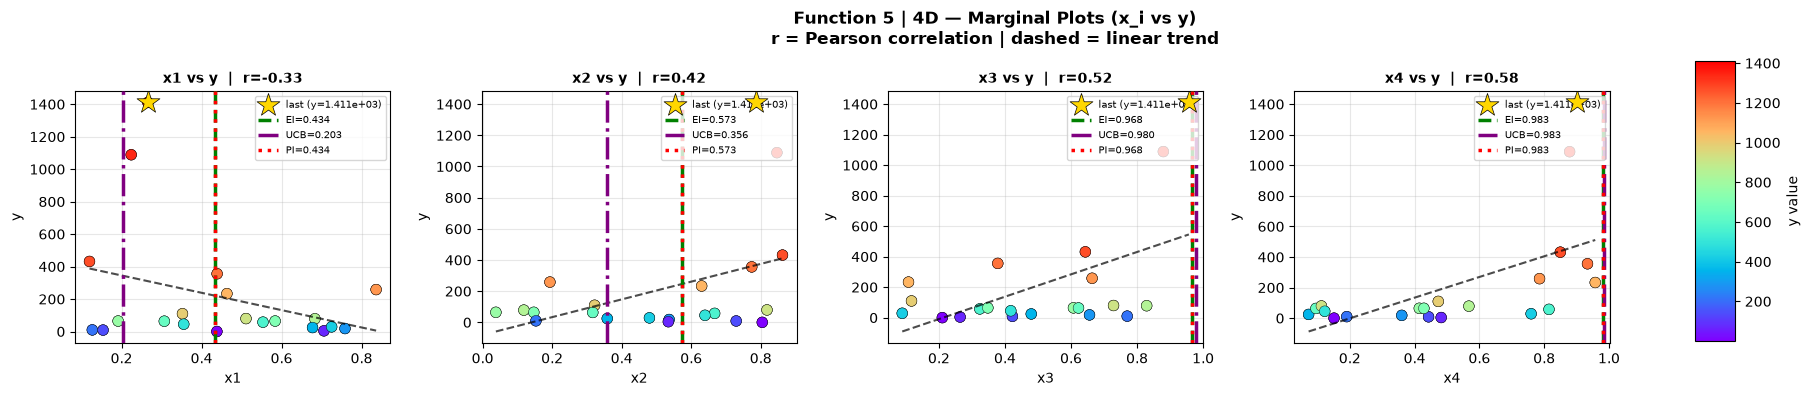

F6: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


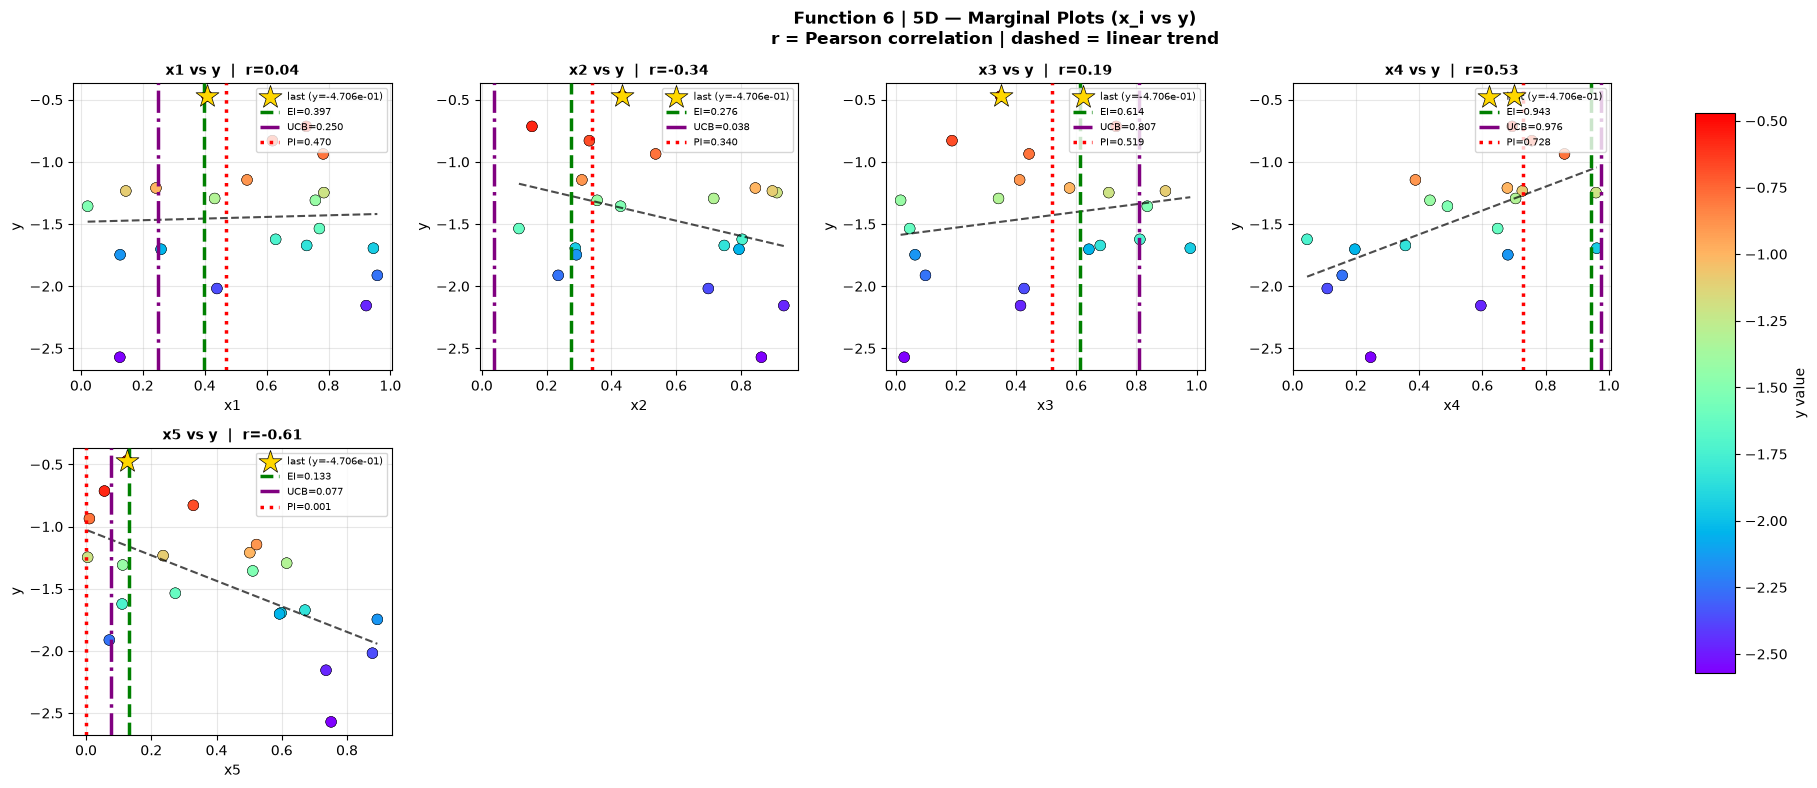

F7: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


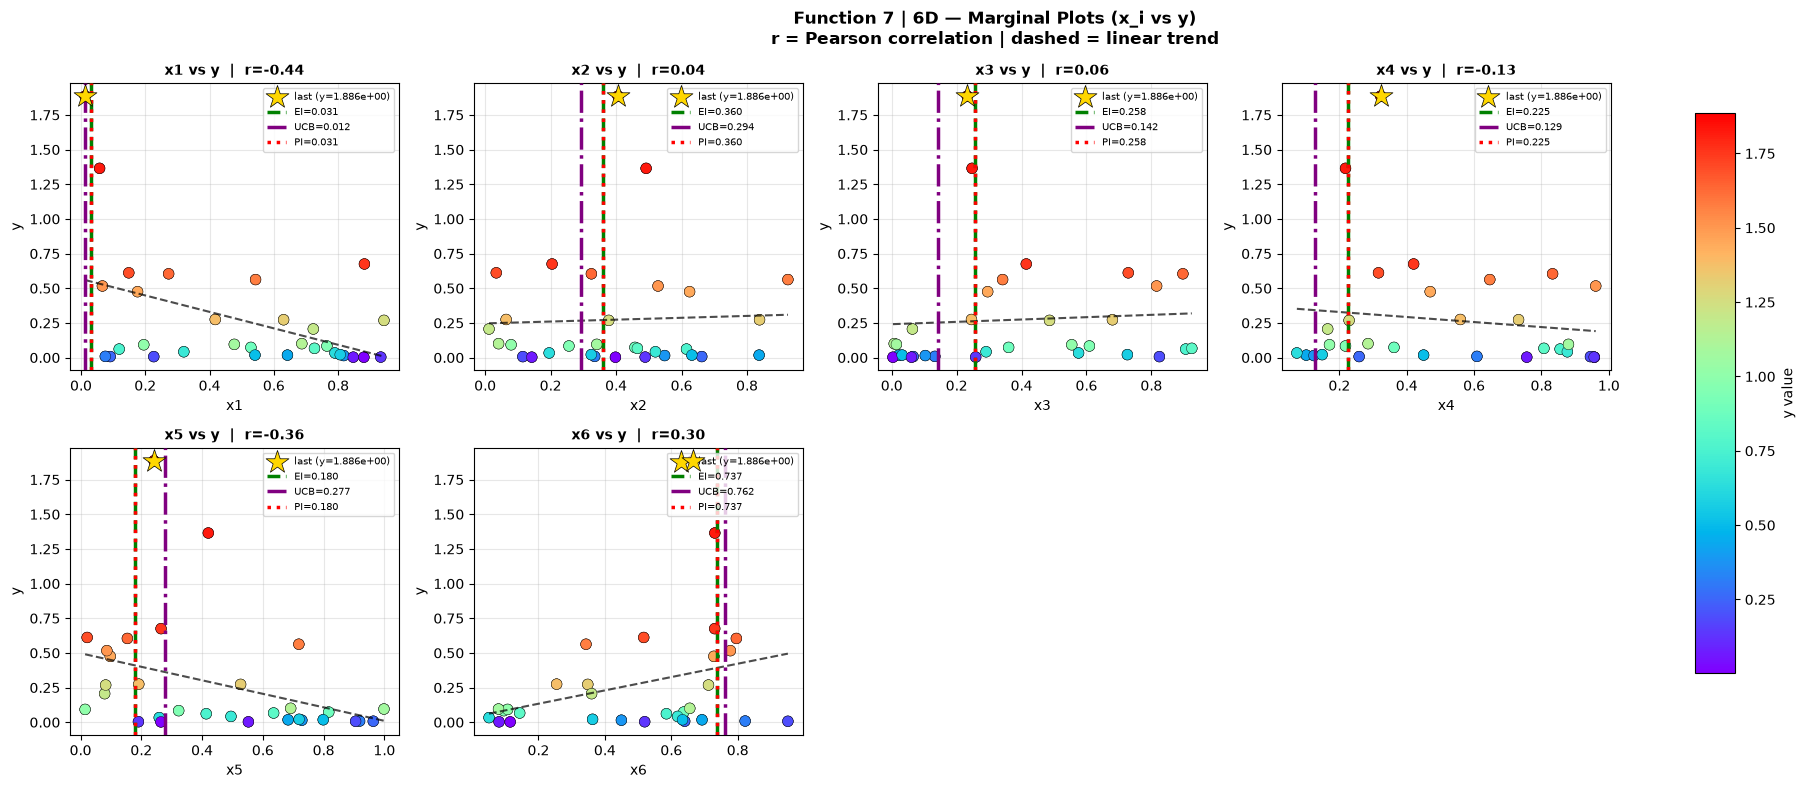

F8: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-10>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


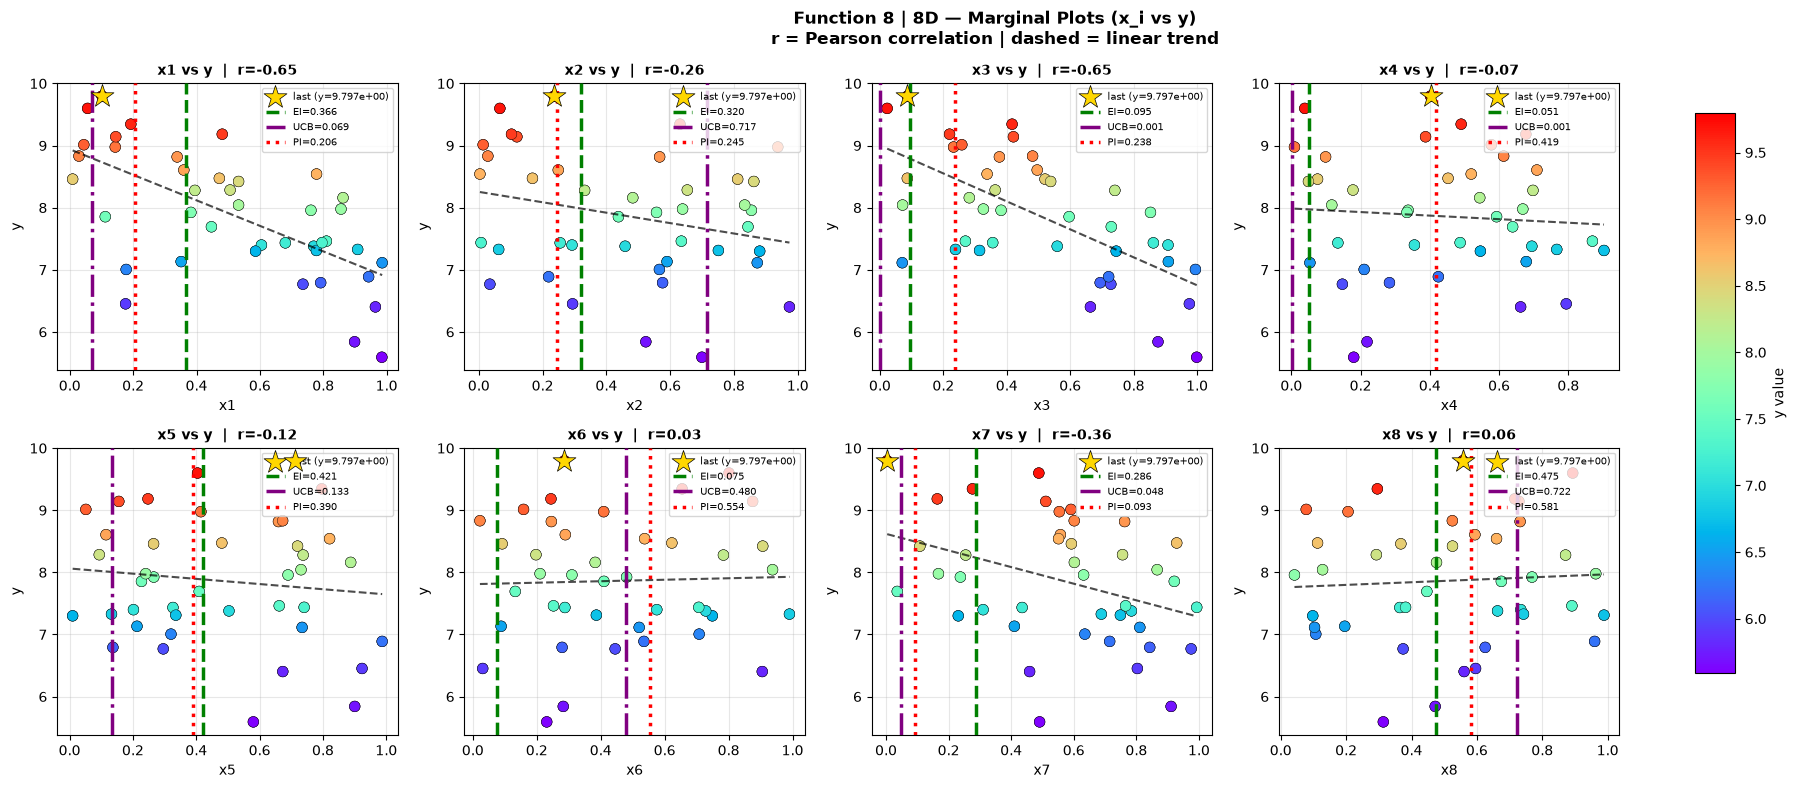

In [10]:
# PLOTTING MARGINAL PLOTS
for fn in range(1, 9):
    plot_function(fn, df_all=df_all)

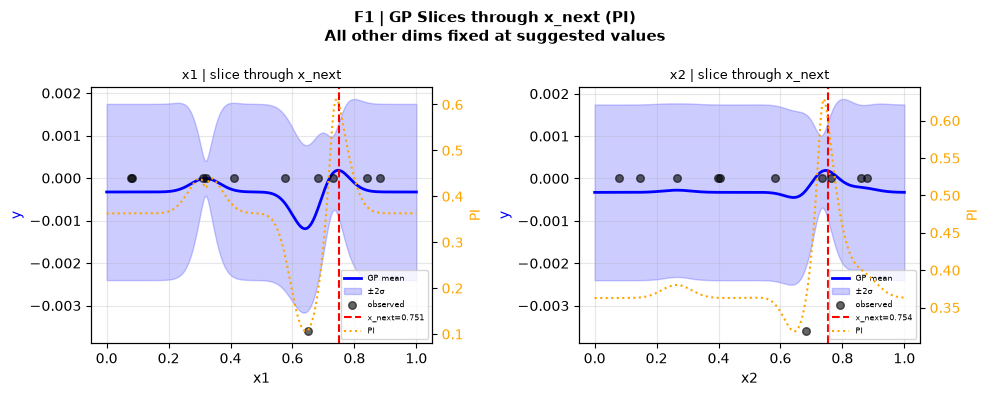

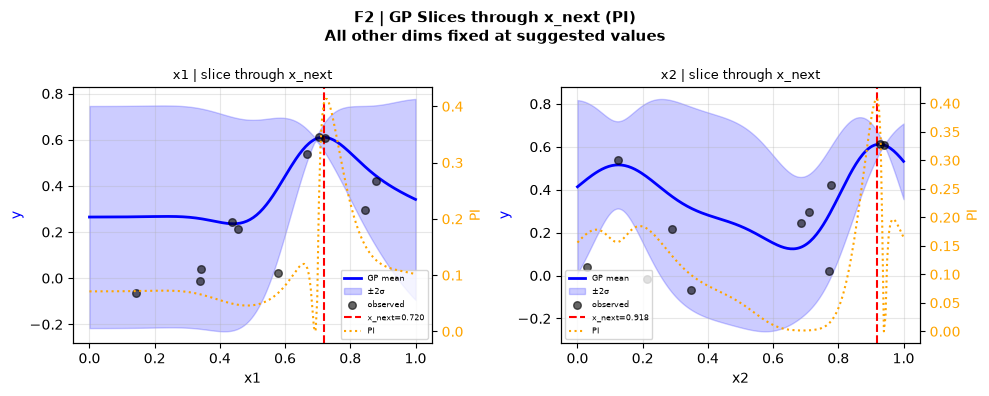

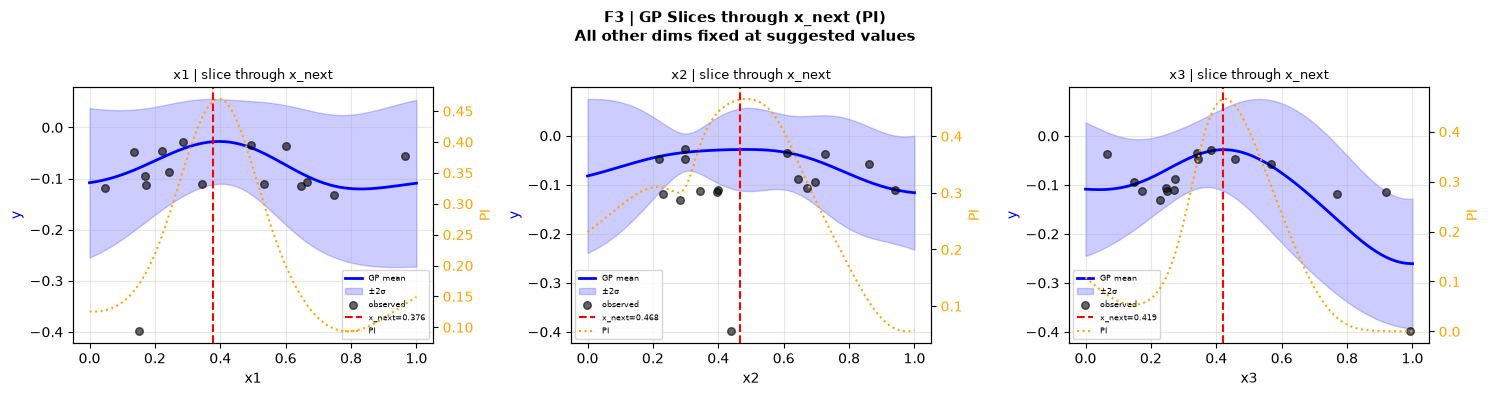

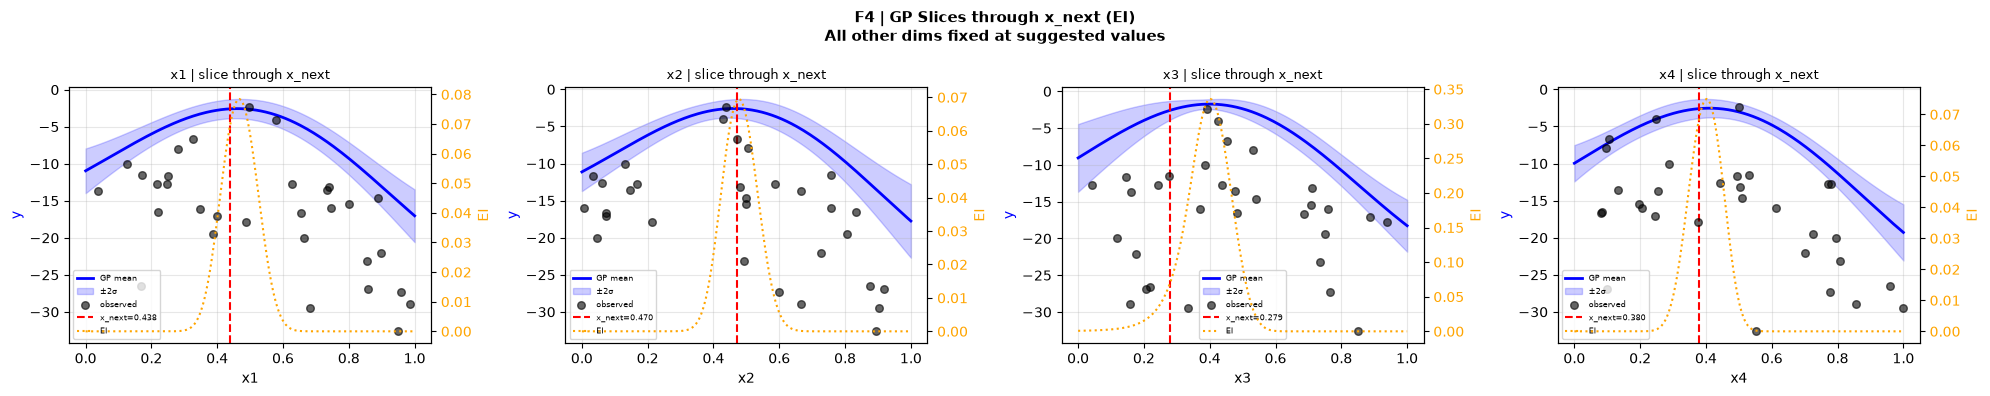

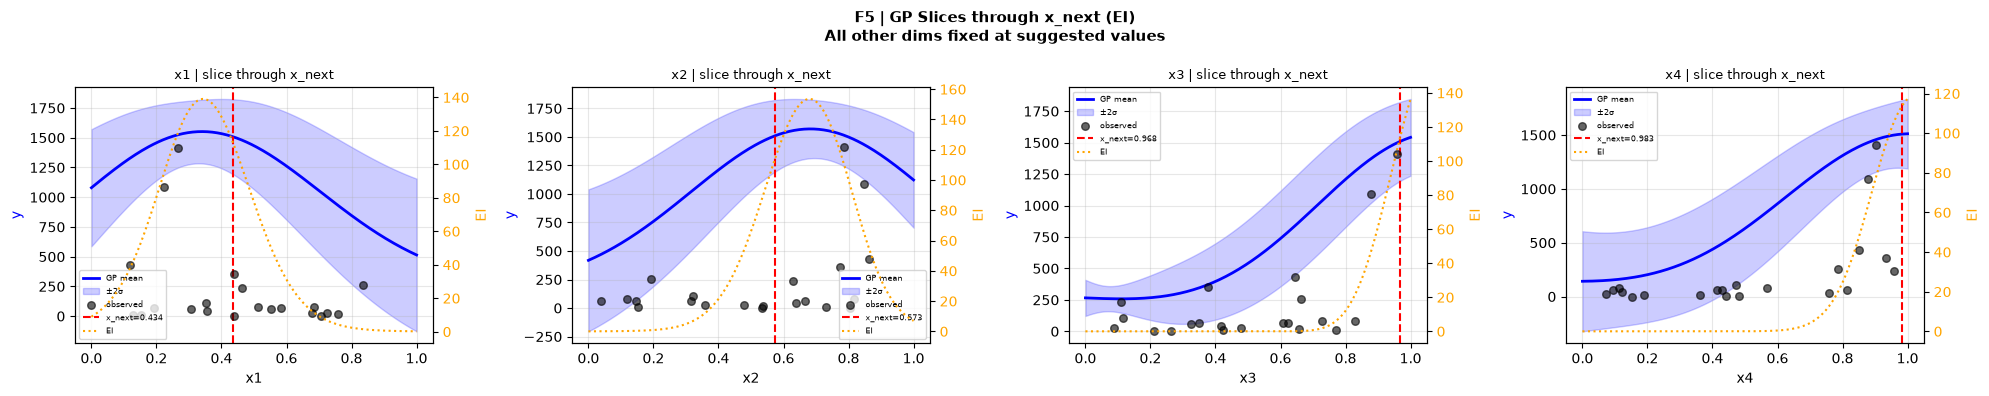

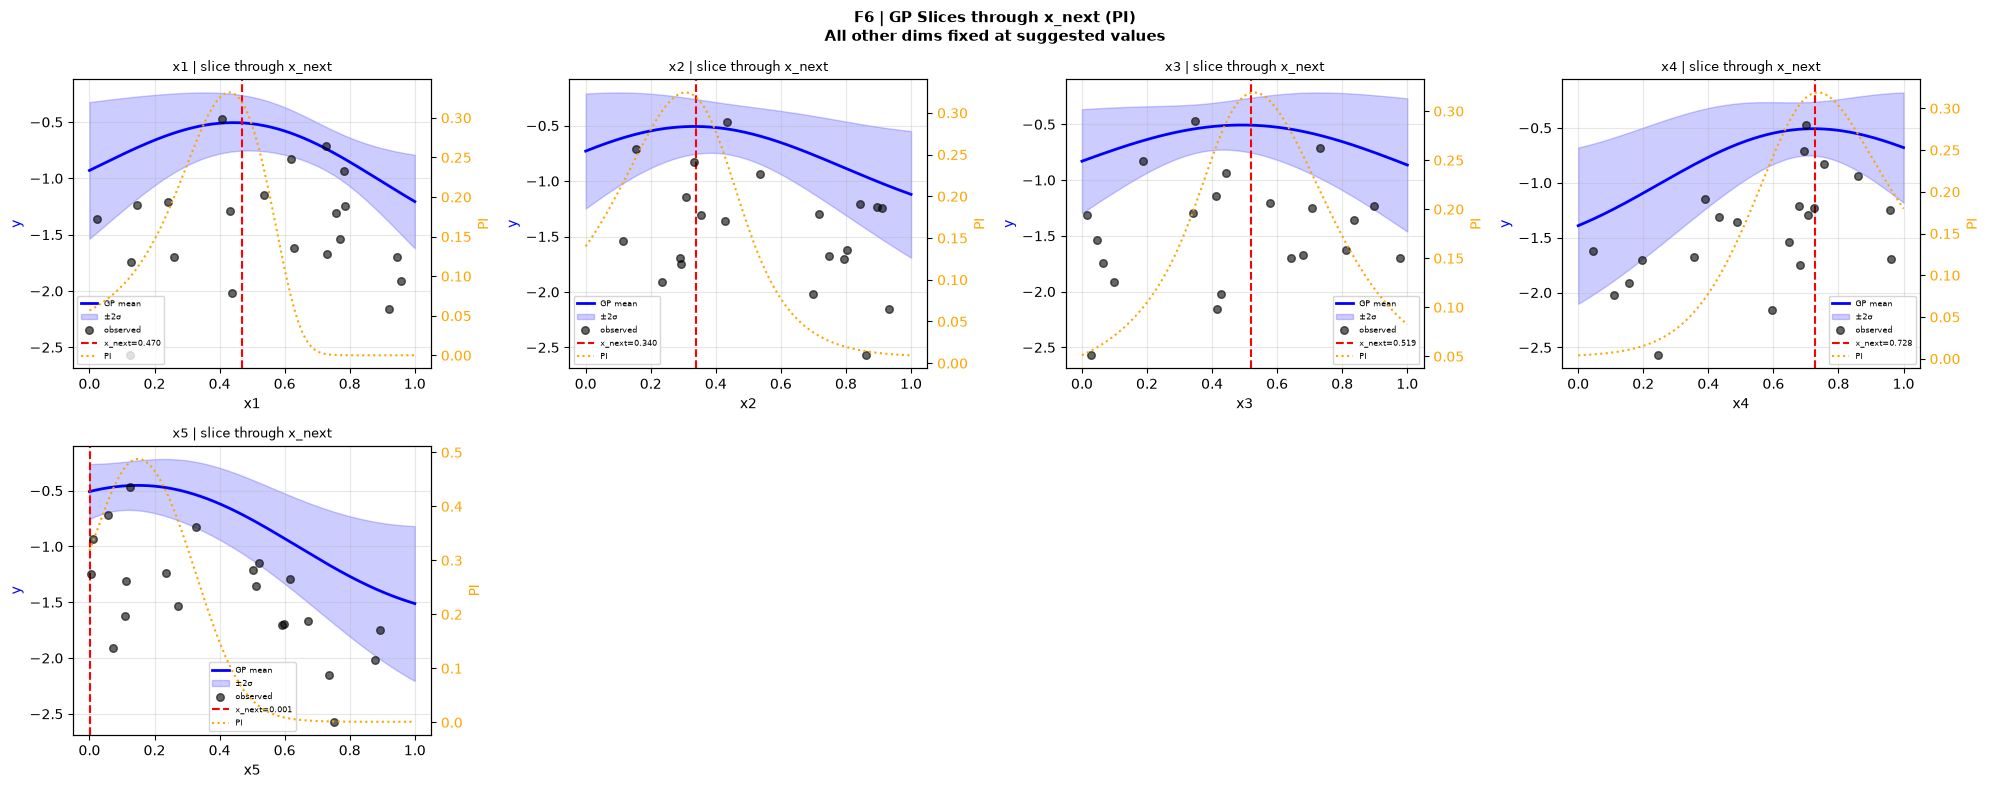

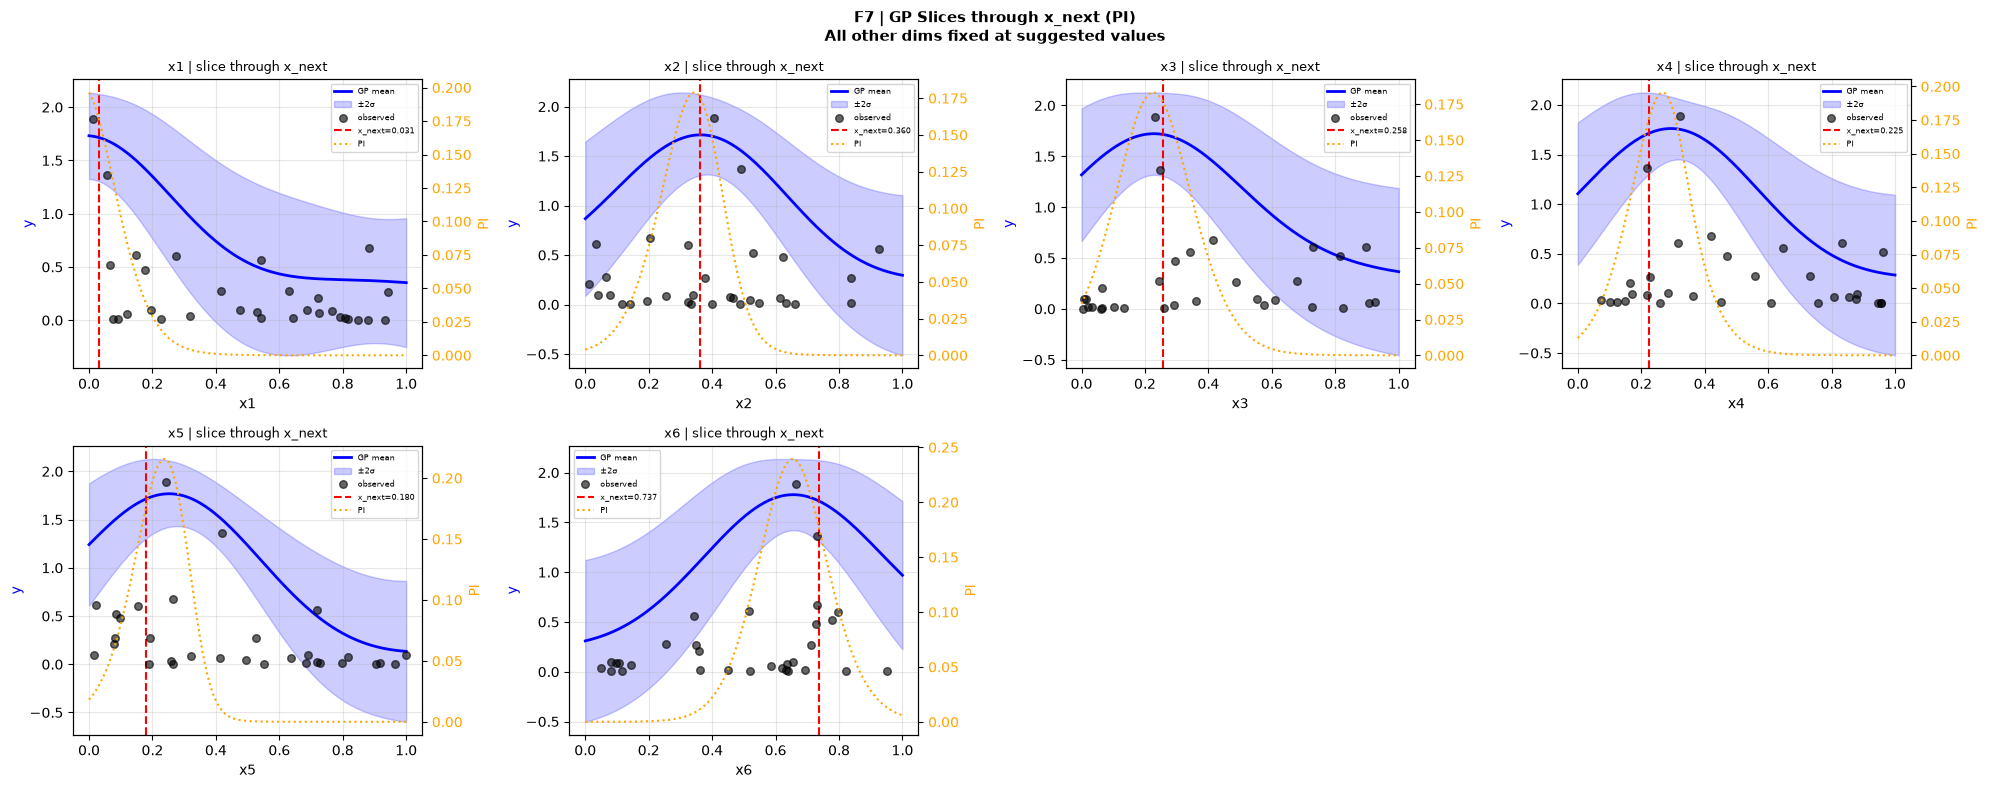

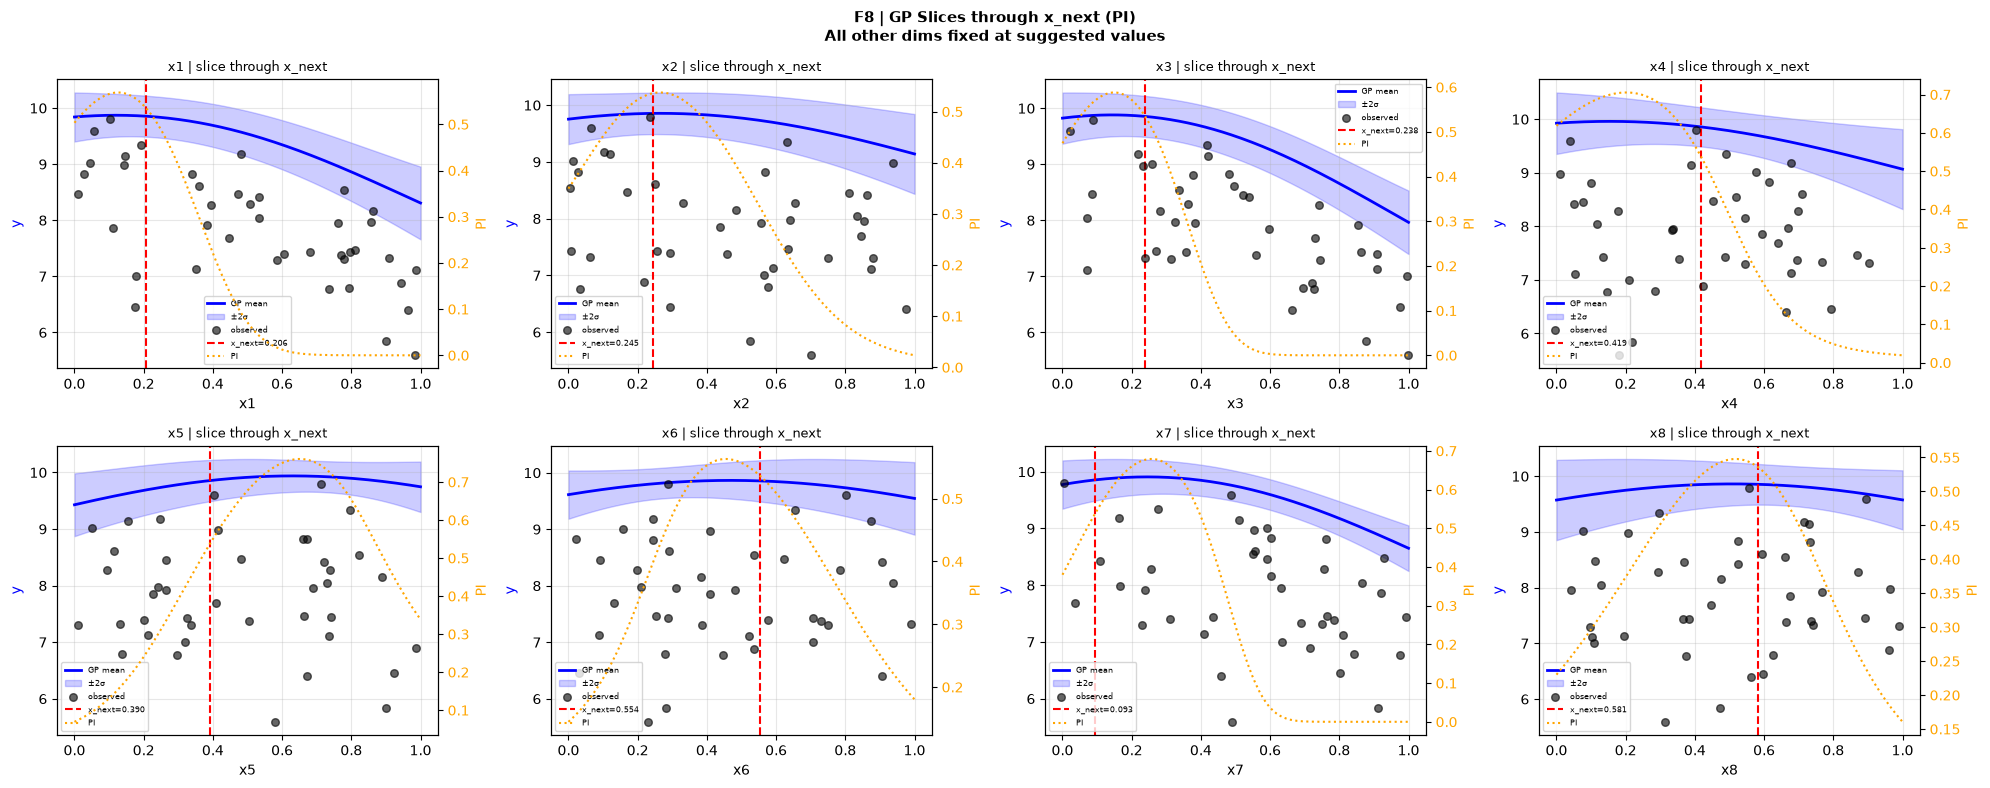

In [11]:
# SLICING GP

def plot_gp_slices(fn_num, gp, df_best, n_points=200):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()

    # Best suggested point as the anchor
    sub   = df_best.loc[fn_num, 'submission']
    x_ref = np.array([float(v) for v in sub.split('-')])
    acq   = df_best.loc[fn_num, 'acquisition']
    y_max = float(df_best.loc[fn_num, 'y_max_so_far'])

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             squeeze=False)

    t = np.linspace(1e-6, 0.999999, n_points)

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax1 = axes[row][col_idx]

        # Build slice: vary dim idx, fix all others at x_ref
        X_slice = np.tile(x_ref, (n_points, 1))
        X_slice[:, idx] = t

        mu, sigma = gp.predict(X_slice, return_std=True)

        # ── GP band
        ax1.plot(t, mu, 'b-', linewidth=2, label='GP mean')
        ax1.fill_between(t, mu - 2*sigma, mu + 2*sigma,
                         alpha=0.2, color='blue', label='±2σ')
        ax1.scatter(X[col], y, color='black', s=30, zorder=5,
                    alpha=0.6, label='observed')
        ax1.axvline(x_ref[idx], color='red', linestyle='--',
                    linewidth=1.5, label=f'x_next={x_ref[idx]:.3f}')
        ax1.set_xlabel(col)
        ax1.set_ylabel('y', color='blue')
        ax1.set_title(f'{col} | slice through x_next', fontsize=9)
        ax1.grid(True, alpha=0.3)

        # ── Acquisition on twin axis
        ax2 = ax1.twinx()
        if acq == 'EI':
            a_vals = acq_EI(mu, sigma, y_max, all_y[fn_num - 1].values)
        elif acq == 'UCB':
            t_current = len(all_y[fn_num - 1])   # number of observations so far
            d_current = all_X[fn_num - 1].shape[1]
            a_vals = acq_UCB(mu, sigma, t=t_current, d=d_current)
        else:
            a_vals = acq_PI(mu, sigma, y_max, all_y[fn_num - 1].values)

        ax2.plot(t, a_vals, color='orange', linewidth=1.5,
                 linestyle=':', label=f'{acq}')
        ax2.set_ylabel(acq, color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')

        # Combined legend
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1+lines2, labels1+labels2, fontsize=6)

    for idx in range(n_dim, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.suptitle(f'F{fn_num} | GP Slices through x_next ({acq})\n'
                 f'All other dims fixed at suggested values',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

# Usage
for fn in range(1, 9):
    plot_gp_slices(fn, gps[fn], df_best)

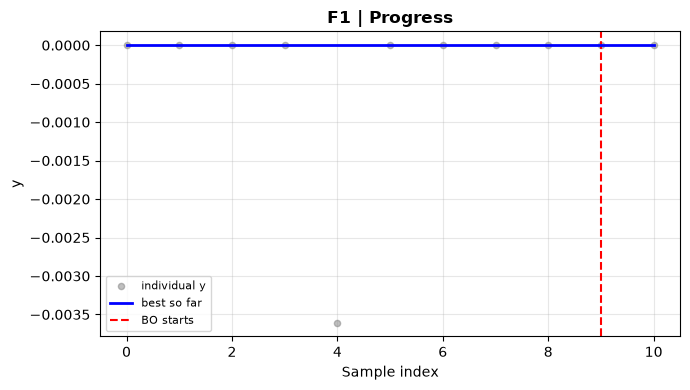

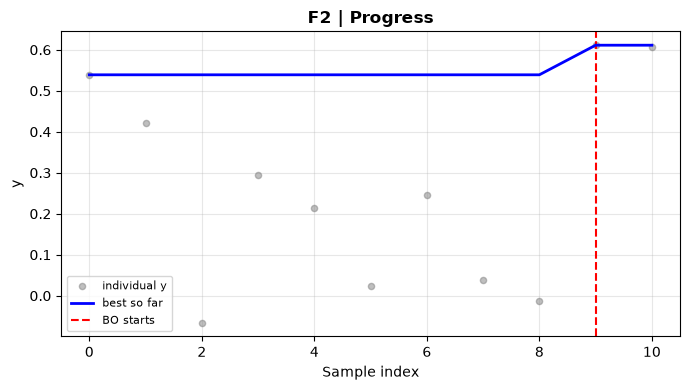

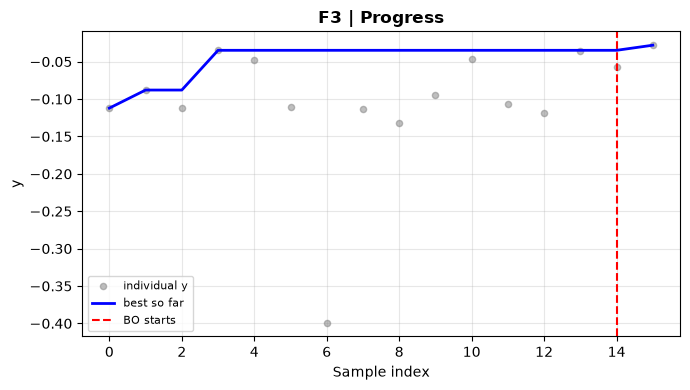

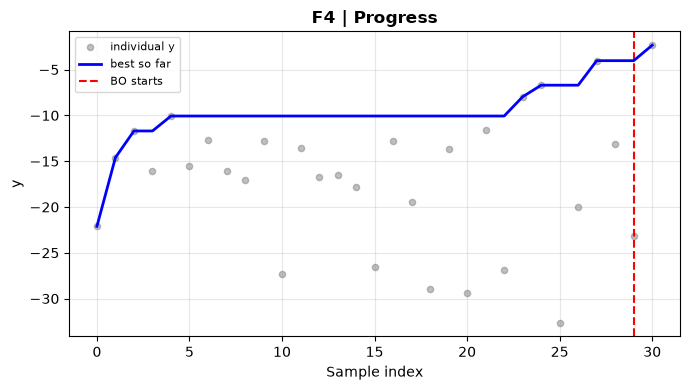

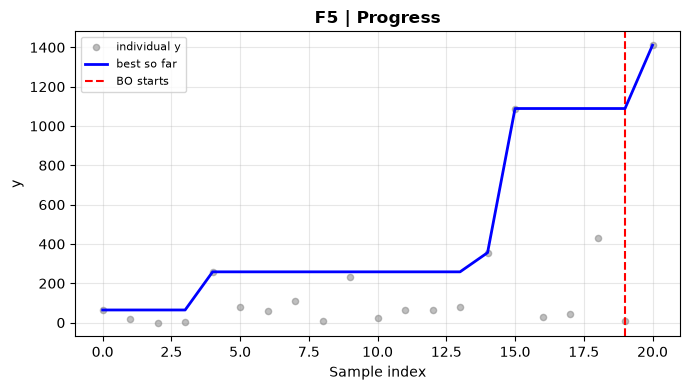

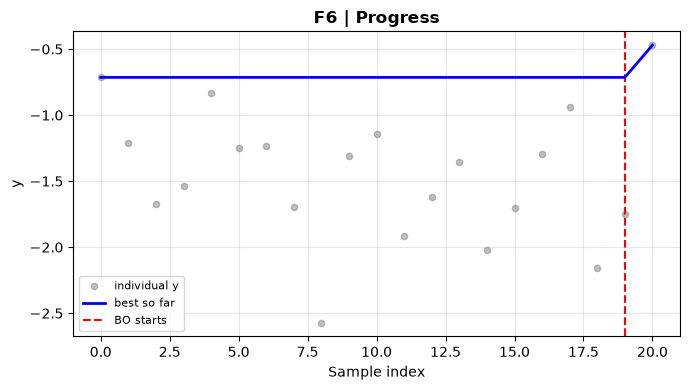

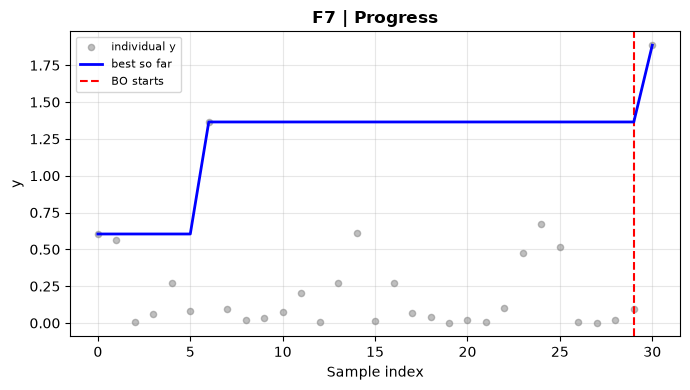

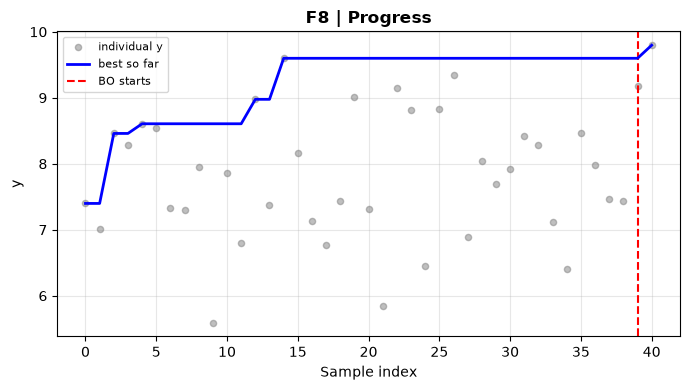

In [12]:
# TRACKING PROGRESS

def plot_progress(fn_num):
    y = all_y[fn_num - 1].values
    n_initial = [10, 10, 15, 30, 20, 20, 30, 40][fn_num - 1]
    
    running_max = np.maximum.accumulate(y)
    iterations = np.arange(len(y))
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    # Individual outputs
    ax.scatter(iterations, y, color='grey', s=20, alpha=0.5, 
               zorder=2, label='individual y')
    
    # Running max
    ax.plot(iterations, running_max, color='blue', 
            linewidth=2, zorder=3, label='best so far')
    
    # Mark boundary between initial data and BO iterations
    ax.axvline(n_initial - 1, color='red', linestyle='--', 
               linewidth=1.5, label='BO starts')
    
    ax.set_xlabel('Sample index')
    ax.set_ylabel('y')
    ax.set_title(f'F{fn_num} | Progress', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for fn in range(1, 9):
    plot_progress(fn)